# Statistical K-Means — 6 EOFs Exploration

**Purpose:** Explore whether 6 EOFs (instead of 8) is a better justified choice based on the explained variance curve.

**Key question:** How much variance do 6 EOFs explain exactly, and is that enough?

**Approach:**
- First fit PCA with ALL components — no truncation
- Print an exact variance table for every k from 1 to 20
- Plot the curve to visualize the elbow
- Then refit with exactly 6 EOFs and run the full analysis

In [2]:
%load_ext autoreload
%autoreload 2

from sklearn.model_selection import GroupShuffleSplit
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy

import clustering_functions as cf
import skill_functions as sf
import preprocessing_functions as pf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Parameters

In [3]:
import os, random

g0                = 9.80665
djf_months        = [12, 1, 2]

cluster_number    = 4
pr_cluster_number = 4
N_EOFS            = 6          # number of EOFs to use
filepath          = "results/statistical_kmeans_6eofs_djf/"

HOLDOUT_FRAC  = 0.30
RANDOM_STATE  = 42
K_MAX         = 8

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.makedirs(filepath, exist_ok=True)
print(f"Results will be saved to: {filepath}")

Results will be saved to: results/statistical_kmeans_6eofs_djf/


### Load ERA5 Z500 (DJF, 1979-2020)

In [4]:
z500 = pf.preprocess_dataset(
    filename              = '../data.nosync/era5_z500_daily_250_atlantic_1940_2022.nc',
    variable_name         = 'z',
    multiplication_factor = 1 / g0,
    geographical_filter   = 'new atlantic',
    months_filter         = djf_months,
    anomalies             = True,
    normalization         = False,
    rolling_window        = 5)

z500 = z500.where(z500['time.year'] > 1978, drop=True)
z500 = z500.where(z500['time.year'] < 2021, drop=True)

weights = np.cos(np.deg2rad(z500.latitude))
z500    = z500 * weights
z500    = z500 / z500.std()

print(f"Z500 DJF shape: {z500.shape}")

Z500 DJF shape: (3791, 25, 33)


### Load MSWEP Precipitation (DJF, 1979-2020)

In [5]:
pr_spatial = xr.open_dataset('../data.nosync/MSWEP_pr_total_DJF.nc')['precipitation']
pr_spatial = pr_spatial.where(pr_spatial['time.year'] < 2021, drop=True)

print(f"pr_spatial shape: {pr_spatial.shape}")
assert z500.shape[0] == pr_spatial.shape[0]
print("Time alignment OK.")

pr_spatial shape: (3791, 150, 160)
Time alignment OK.


### Winter-year group key

In [6]:
times = pd.to_datetime(z500.time.values)

winter_year = np.array([t.year if t.month == 12 else t.year - 1
                        for t in times])

unique_winters = np.sort(np.unique(winter_year))
print(f"Total DJF days : {len(times)}")
print(f"Unique winters : {len(unique_winters)}")

Total DJF days : 3791
Unique winters : 43


### Train / holdout split (same as all other notebooks)

In [7]:
X_raw = cf.reshape_data_for_clustering(z500)

gss = GroupShuffleSplit(n_splits=1, test_size=HOLDOUT_FRAC, random_state=RANDOM_STATE)
train_idx, holdout_idx = next(gss.split(X_raw, groups=winter_year))

train_winters   = sorted(set(winter_year[train_idx].tolist()))
holdout_winters = sorted(set(winter_year[holdout_idx].tolist()))

X_train_raw   = X_raw[train_idx]
X_holdout_raw = X_raw[holdout_idx]

print(f"Training days : {len(train_idx)}   ({len(train_winters)} winters)")
print(f"Holdout  days : {len(holdout_idx)}   ({len(holdout_winters)} winters)")

Training days : 2619   (30 winters)
Holdout  days : 1172   (13 winters)


### Step 1 — Fit FULL PCA (no truncation yet)

We first fit PCA keeping ALL components.
This lets us inspect exactly how much variance any number of EOFs explains
before committing to a choice.

In [8]:
# Fit full PCA on training days — keep all components
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_raw)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

print("Full PCA fitted on training days.")
print(f"Total components available: {len(pca_full.explained_variance_ratio_)}")

Full PCA fitted on training days.
Total components available: 825


### Step 2 — Exact variance table

This table gives the **precise** cumulative variance for every number of EOFs from 1 to 20.
No need to read from the curve — the number is printed directly.

In [9]:
print("=" * 55)
print(f"  {'EOFs':>5}  {'Individual (%)':>15}  {'Cumulative (%)':>15}")
print("=" * 55)
for i in range(20):
    indiv = pca_full.explained_variance_ratio_[i] * 100
    cumul = cumvar[i] * 100
    marker = " ← selected" if (i + 1) == N_EOFS else ""
    marker_8 = " ← 8 EOFs (previous)" if (i + 1) == 8 else ""
    print(f"  {i+1:>5}  {indiv:>14.2f}%  {cumul:>14.2f}%{marker}{marker_8}")
print("=" * 55)
print(f"\nWith {N_EOFS} EOFs: cumulative variance = {cumvar[N_EOFS-1]*100:.2f}%")
print(f"With 8 EOFs      : cumulative variance = {cumvar[7]*100:.2f}%")
print(f"Difference       : {(cumvar[7] - cumvar[N_EOFS-1])*100:.2f}%")

   EOFs   Individual (%)   Cumulative (%)
      1           27.37%           27.37%
      2           19.87%           47.24%
      3           17.47%           64.70%
      4            9.99%           74.70%
      5            6.35%           81.04%
      6            3.16%           84.21% ← selected
      7            3.07%           87.28%
      8            2.93%           90.21% ← 8 EOFs (previous)
      9            1.78%           91.99%
     10            1.44%           93.43%
     11            1.00%           94.43%
     12            0.94%           95.37%
     13            0.69%           96.06%
     14            0.59%           96.65%
     15            0.59%           97.24%
     16            0.34%           97.58%
     17            0.28%           97.86%
     18            0.26%           98.11%
     19            0.22%           98.33%
     20            0.21%           98.54%

With 6 EOFs: cumulative variance = 84.21%
With 8 EOFs      : cumulative variance = 90.

### Step 3 — Explained variance curve

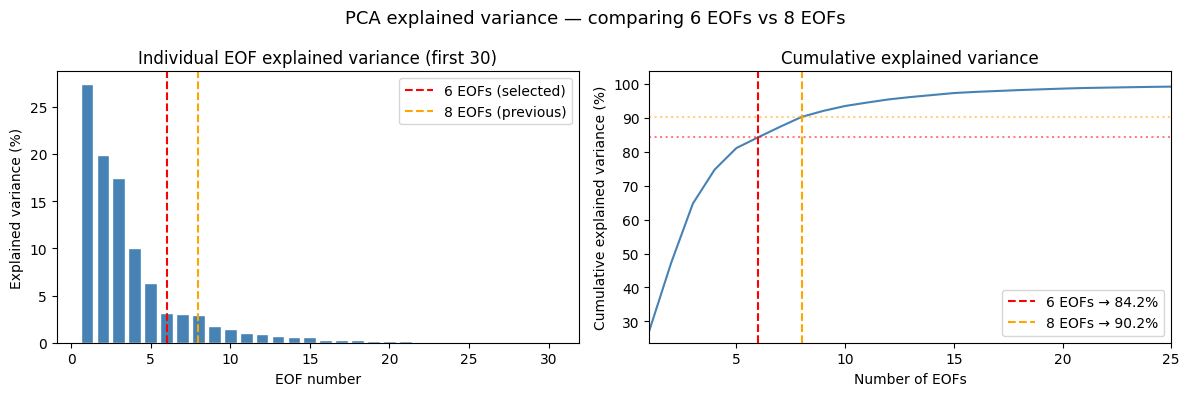

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: individual variance
axes[0].bar(np.arange(1, 31), pca_full.explained_variance_ratio_[:30] * 100,
            color='steelblue', edgecolor='white')
axes[0].axvline(N_EOFS, color='red',    linestyle='--', label=f'{N_EOFS} EOFs (selected)')
axes[0].axvline(8,      color='orange', linestyle='--', label='8 EOFs (previous)')
axes[0].set_xlabel('EOF number')
axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Individual EOF explained variance (first 30)')
axes[0].legend()

# Right: cumulative variance
axes[1].plot(np.arange(1, len(cumvar)+1), cumvar * 100, color='steelblue')
axes[1].axvline(N_EOFS, color='red',    linestyle='--',
                label=f'{N_EOFS} EOFs → {cumvar[N_EOFS-1]*100:.1f}%')
axes[1].axvline(8,      color='orange', linestyle='--',
                label=f'8 EOFs → {cumvar[7]*100:.1f}%')
axes[1].axhline(cumvar[N_EOFS-1]*100, color='red',    linestyle=':', alpha=0.5)
axes[1].axhline(cumvar[7]*100,        color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of EOFs')
axes[1].set_ylabel('Cumulative explained variance (%)')
axes[1].set_title('Cumulative explained variance')
axes[1].legend()
axes[1].set_xlim([1, 25])

plt.suptitle(f'PCA explained variance — comparing {N_EOFS} EOFs vs 8 EOFs', fontsize=13)
plt.tight_layout()
plt.savefig(filepath + 'pca_variance_comparison.png', dpi=150)
plt.show()

### Step 4 — Refit PCA with {N_EOFS} EOFs and project data

In [11]:
# Refit with chosen number of EOFs
pca = PCA(n_components=N_EOFS, random_state=RANDOM_STATE)
pca.fit(X_train_raw)

X_train_pca   = pca.transform(X_train_raw)
X_holdout_pca = pca.transform(X_holdout_raw)

print(f"PCA refitted with {N_EOFS} EOFs")
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Training EOF shape : {X_train_pca.shape}")
print(f"Holdout  EOF shape : {X_holdout_pca.shape}")

PCA refitted with 6 EOFs
Variance explained: 84.21%
Training EOF shape : (2619, 6)
Holdout  EOF shape : (1172, 6)


### Step 5 — K selection: elbow and silhouette (training only, no precipitation)

  k=2  inertia=1396596.3  silhouette=0.2041
  k=3  inertia=1195620.1  silhouette=0.1752
  k=4  inertia=1049051.5  silhouette=0.1801
  k=5  inertia=952257.7  silhouette=0.1719
  k=6  inertia=885214.9  silhouette=0.1720
  k=7  inertia=836308.9  silhouette=0.1601
  k=8  inertia=792547.5  silhouette=0.1591


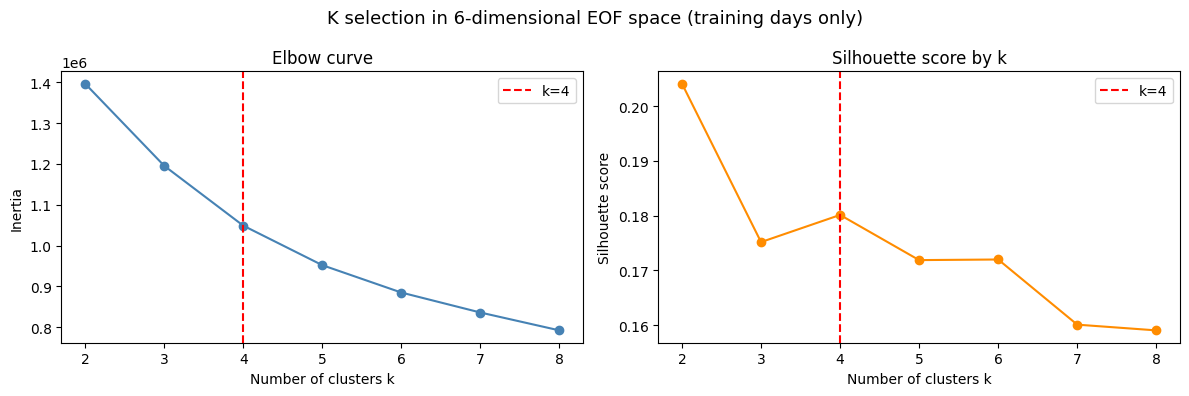

In [12]:
inertias    = []
silhouettes = []
k_values    = list(range(2, K_MAX + 1))

for k in k_values:
    km_tmp = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km_tmp.fit(X_train_pca)
    inertias.append(km_tmp.inertia_)
    sil = silhouette_score(X_train_pca, km_tmp.labels_)
    silhouettes.append(sil)
    print(f"  k={k}  inertia={km_tmp.inertia_:.1f}  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, inertias, 'o-', color='steelblue')
axes[0].axvline(cluster_number, color='red', linestyle='--', label=f'k={cluster_number}')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow curve')
axes[0].legend()

axes[1].plot(k_values, silhouettes, 'o-', color='darkorange')
axes[1].axvline(cluster_number, color='red', linestyle='--', label=f'k={cluster_number}')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score by k')
axes[1].legend()

plt.suptitle(f'K selection in {N_EOFS}-dimensional EOF space (training days only)', fontsize=13)
plt.tight_layout()
plt.savefig(filepath + 'k_selection.png', dpi=150)
plt.show()

### Step 6 — Fit final K-Means in EOF space (training only)

In [13]:
print(f"Fitting K-Means (k={cluster_number}) in {N_EOFS}-dimensional EOF space ...")
kmeans = KMeans(n_clusters=cluster_number, n_init=20, random_state=RANDOM_STATE)
kmeans.fit(X_train_pca)

labels_train   = kmeans.predict(X_train_pca)
labels_holdout = kmeans.predict(X_holdout_pca)

def distances_to_probs(distances):
    neg_dist = -distances
    neg_dist -= neg_dist.max(axis=1, keepdims=True)
    exp_d = np.exp(neg_dist)
    return exp_d / exp_d.sum(axis=1, keepdims=True)

dist_train   = kmeans.transform(X_train_pca)
dist_holdout = kmeans.transform(X_holdout_pca)
probs_train   = distances_to_probs(dist_train)
probs_holdout = distances_to_probs(dist_holdout)

print("K-Means distribution (training days):")
for k in range(cluster_number):
    n = (labels_train == k).sum()
    print(f"  Cluster {k}: {n} days  ({100*n/len(labels_train):.1f}%)")

Fitting K-Means (k=4) in 6-dimensional EOF space ...
K-Means distribution (training days):
  Cluster 0: 598 days  (22.8%)
  Cluster 1: 718 days  (27.4%)
  Cluster 2: 788 days  (30.1%)
  Cluster 3: 515 days  (19.7%)


### Precipitation — for ordering and evaluation only

In [14]:
pr_values = pr_spatial.values
nt, ny, nx = pr_values.shape
pr_flat = np.reshape(pr_values, [nt, ny * nx], order='F')

pr_flat_train   = pr_flat[train_idx]
pr_flat_holdout = pr_flat[holdout_idx]

q95_threshold  = np.percentile(pr_flat_train, 95, axis=0)
exceed_train   = (pr_flat_train   >= q95_threshold).astype(np.float32)
exceed_holdout = (pr_flat_holdout >= q95_threshold).astype(np.float32)

def flat_to_xarray(flat_exceed, time_coords, pr_ref):
    data_3d = np.reshape(flat_exceed, [len(time_coords), ny, nx], order='F')
    return xr.DataArray(
        data_3d,
        coords={'time': time_coords,
                'latitude':  pr_ref.latitude.values,
                'longitude': pr_ref.longitude.values},
        dims=['time', 'latitude', 'longitude'],
        name='precipitation')

threshold_qn95_train   = flat_to_xarray(exceed_train,   pr_spatial.time[train_idx],   pr_spatial)
threshold_qn95_holdout = flat_to_xarray(exceed_holdout, pr_spatial.time[holdout_idx], pr_spatial)

kmeans_pr = KMeans(n_clusters=pr_cluster_number, n_init=10, random_state=RANDOM_STATE)
kmeans_pr.fit(pr_flat_train)
pr_labels_train   = kmeans_pr.predict(pr_flat_train)
pr_labels_holdout = kmeans_pr.predict(pr_flat_holdout)

print(f"Q95 exceedance fraction (training): {exceed_train.mean():.3f}  (expect ~0.05)")

Q95 exceedance fraction (training): 0.051  (expect ~0.05)


### Order clusters wettest → driest (training only)

In [15]:
pr_total_train = pr_spatial.isel(time=train_idx).sum(dim=['latitude', 'longitude']).values

precip_sum = (pd.DataFrame({'values': pr_total_train, 'label': labels_train.astype(int)})
              .groupby('label')['values'].sum().reset_index()
              .rename(columns={'label': 'index_old'})
              .sort_values('values', ascending=False).reset_index(drop=True))
precip_sum['index_new'] = np.arange(len(precip_sum))
col_order = precip_sum['index_old'].values.tolist()

def reorder_labels(raw_labels):
    mapping = {old: new for new, old in enumerate(col_order)}
    return np.array([mapping[int(l)] for l in raw_labels])

labels_train_reord   = reorder_labels(labels_train)
labels_holdout_reord = reorder_labels(labels_holdout)
probs_train_reord    = probs_train[:,   col_order]
probs_holdout_reord  = probs_holdout[:, col_order]

regime_names = [f'Regime {i+1}' for i in range(cluster_number)]
print("Cluster ordering by precipitation (training only):")
print(precip_sum)

Cluster ordering by precipitation (training only):
   index_old      values  index_new
0          3  14976159.0          0
1          2   9631186.0          1
2          0   9152874.0          2
3          1   7019675.0          3


### Statistical evaluation (training days, Z500 only)

In [16]:
print("=" * 60)
print(f"  STATISTICAL EVALUATION ({N_EOFS} EOFs)")
print("=" * 60)

sil = silhouette_score(X_train_pca, labels_train)
db  = davies_bouldin_score(X_train_pca, labels_train)
ch  = calinski_harabasz_score(X_train_pca, labels_train)

print(f"\n1. Silhouette score        : {sil:.4f}")
print(f"2. Davies-Bouldin index    : {db:.4f}")
print(f"3. Calinski-Harabasz score : {ch:.1f}")

print(f"\n4. Occurrence frequency (training):")
for k in range(cluster_number):
    n = (labels_train_reord == k).sum()
    print(f"   {regime_names[k]}: {n} days  ({100*n/len(labels_train_reord):.1f}%)")

print(f"\n5. Regime persistence (training):")
persistence_train = cf.calculate_regime_persistence(labels_train_reord)
for k, v in persistence_train.items():
    print(f"   {regime_names[int(k)]}: {v:.1f} days avg")
avg_pers_train = np.mean(list(persistence_train.values()))
print(f"   Average: {avg_pers_train:.1f} days")
print("=" * 60)

  STATISTICAL EVALUATION (6 EOFs)

1. Silhouette score        : 0.1801
2. Davies-Bouldin index    : 1.5500
3. Calinski-Harabasz score : 609.5

4. Occurrence frequency (training):
   Regime 1: 515 days  (19.7%)
   Regime 2: 788 days  (30.1%)
   Regime 3: 598 days  (22.8%)
   Regime 4: 718 days  (27.4%)

5. Regime persistence (training):
   Regime 1: 7.9 days avg
   Regime 2: 10.1 days avg
   Regime 3: 7.9 days avg
   Regime 4: 8.1 days avg
   Average: 8.5 days


### Z500 composite maps — 4 regimes

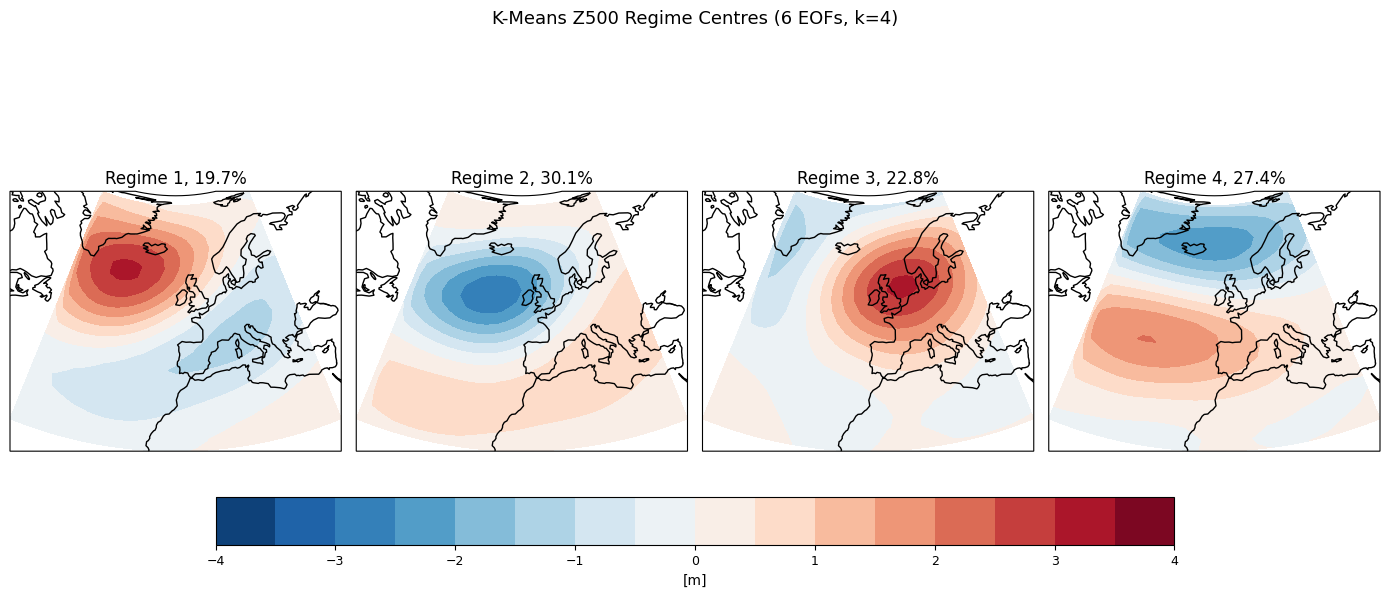

In [17]:
centroids_pca  = kmeans.cluster_centers_[col_order]
centroids_z500 = pca.inverse_transform(centroids_pca)
centroids_z500 = centroids_z500.reshape(cluster_number, z500.shape[1], z500.shape[2], order='F')

centroids_xr = xr.DataArray(
    centroids_z500,
    coords={'label': np.arange(cluster_number),
            'latitude':  z500.latitude.values,
            'longitude': z500.longitude.values},
    dims=['label', 'latitude', 'longitude'])
centroids_xr = centroids_xr / np.cos(np.deg2rad(centroids_xr.latitude))

cf.visualise_contourplot(
    cluster_centers = centroids_xr,
    unit            = '[m]',
    regime_names    = regime_names,
    vmin=-4, vmax=4.5, steps=0.5,
    color_scheme    = 'RdBu_r',
    labels_data     = X_train_pca,
    labels          = labels_train_reord,
    borders         = False,
    col_number      = cluster_number,
    projection      = ccrs.AlbersEqualArea(central_longitude=-10, central_latitude=50))

plt.suptitle(f'K-Means Z500 Regime Centres ({N_EOFS} EOFs, k={cluster_number})', fontsize=13)
plt.savefig(filepath + 'regime_centers_z500.png', dpi=150)
plt.show()

### Holdout evaluation — occurrence and persistence

In [18]:
print("=" * 60)
print(f"  HOLDOUT EVALUATION ({N_EOFS} EOFs, 13 unseen winters)")
print("=" * 60)

print(f"\nOccurrence frequency (holdout):")
for k in range(cluster_number):
    n = (labels_holdout_reord == k).sum()
    print(f"   {regime_names[k]}: {n} days  ({100*n/len(labels_holdout_reord):.1f}%)")

persistence_holdout = cf.calculate_regime_persistence(labels_holdout_reord)
print(f"\nRegime persistence (holdout):")
for k, v in persistence_holdout.items():
    print(f"   {regime_names[int(k)]}: {v:.1f} days avg")
avg_pers_holdout = np.mean(list(persistence_holdout.values()))
print(f"   Average: {avg_pers_holdout:.1f} days")
print("=" * 60)

  HOLDOUT EVALUATION (6 EOFs, 13 unseen winters)

Occurrence frequency (holdout):
   Regime 1: 336 days  (28.7%)
   Regime 2: 311 days  (26.5%)
   Regime 3: 265 days  (22.6%)
   Regime 4: 260 days  (22.2%)

Regime persistence (holdout):
   Regime 1: 8.0 days avg
   Regime 2: 7.8 days avg
   Regime 3: 5.4 days avg
   Regime 4: 6.3 days avg
   Average: 6.9 days


### BSS evaluation — holdout only

In [19]:
print("=" * 60)
print(f"  MOROCCO PRECIPITATION SKILL SCORES ({N_EOFS} EOFs)")
print("=" * 60)

bss_95_holdout = sf.calculate_95pc_skill_score_probabilistic(
    cluster_number_z500        = cluster_number,
    z500_cluster_probabilities = probs_holdout_reord,
    pr_spatial                 = pr_spatial.isel(time=holdout_idx))
print(f"  BSS 95th percentile (holdout): {bss_95_holdout:.4f}")

bss_cluster_holdout = sf.calculate_cluster_skill_score_probabilistic(
    cluster_number_pr          = pr_cluster_number,
    cluster_number_z500        = cluster_number,
    pr_cluster_labels          = pr_labels_holdout,
    z500_cluster_probabilities = probs_holdout_reord)
print(f"  BSS cluster         (holdout): {bss_cluster_holdout:.4f}")

bss_tercile_holdout = sf.calculate_tercile_skill_score_probabilistic(
    cluster_number_z500        = cluster_number,
    z500_cluster_probabilities = probs_holdout_reord,
    pr_spatial                 = pr_spatial.isel(time=holdout_idx))
print(f"  BSS tercile (holdout, mean):   {float(bss_tercile_holdout.mean()):.4f}")
print("=" * 60)

  MOROCCO PRECIPITATION SKILL SCORES (6 EOFs)
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
  BSS 95th percentile (holdout): 0.0273
  BSS cluster         (holdout): 0.0470
  BSS tercile (holdout, mean):   0.0238


### Odds ratio maps — holdout winters

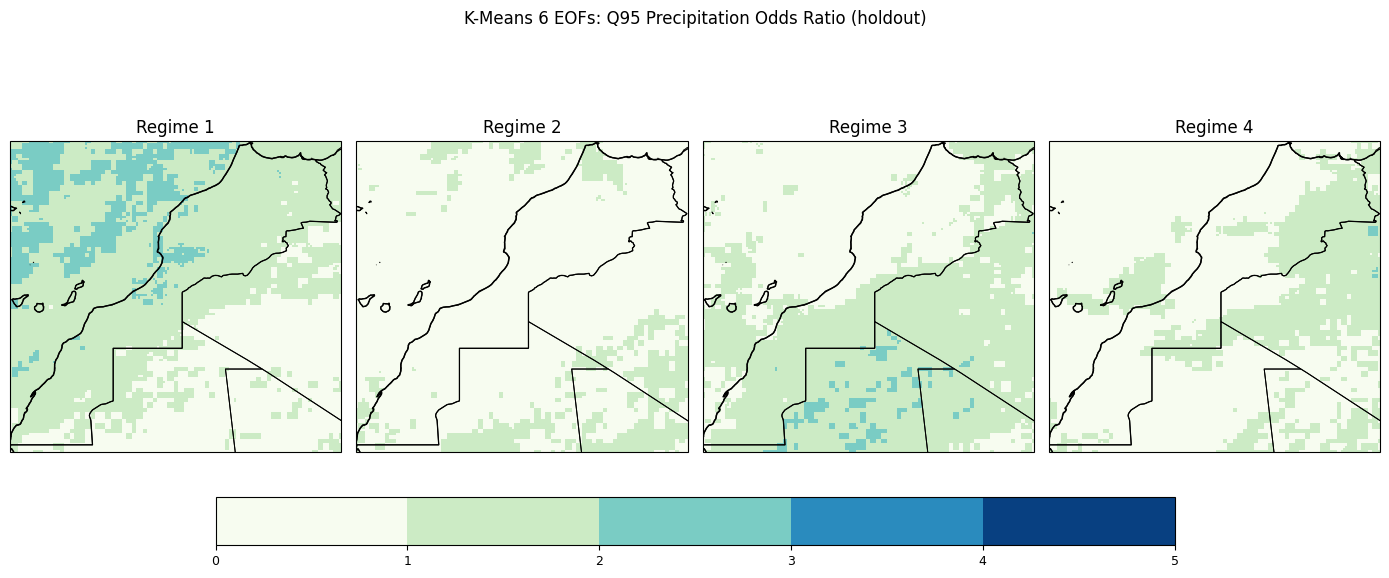

Max odds ratio : 2.52x
Mean odds ratio: 2.33x


In [20]:
pr_qn95_ratio_holdout = cf.calculate_conditional_probability_change_label(
    threshold_matrix = threshold_qn95_holdout,
    labels           = labels_holdout_reord,
    comparison       = 'ratio',
    shift_value      = 0)

cf.visualise_spatial_oddsratio(
    dataset_xarray = pr_qn95_ratio_holdout,
    unit           = '',
    color_scheme   = 'GnBu',
    vmin=0, vmax=5, steps=6,
    title          = f'K-Means {N_EOFS} EOFs: Odds ratio - 95th pct precipitation (holdout)',
    regime_names   = regime_names,
    borders        = True,
    projection     = ccrs.PlateCarree(central_longitude=0),
    col_number     = cluster_number)

plt.suptitle(f'K-Means {N_EOFS} EOFs: Q95 Precipitation Odds Ratio (holdout)', fontsize=12)
plt.savefig(filepath + 'precip_odds_ratio_holdout.png', dpi=150)
plt.show()

or_flat  = pr_qn95_ratio_holdout.values.reshape(cluster_number, -1)
max_or   = np.nanmax(or_flat)
mean_or  = np.mean(np.nanmax(or_flat, axis=1))
print(f"Max odds ratio : {max_or:.2f}x")
print(f"Mean odds ratio: {mean_or:.2f}x")

### Summary — 6 EOFs vs 8 EOFs

In [21]:
print("=" * 60)
print(f"  SUMMARY: {N_EOFS} EOFs vs 8 EOFs")
print("=" * 60)
print(f"\n  Variance explained:")
print(f"    {N_EOFS} EOFs : {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"    8 EOFs : {cumvar[7]*100:.2f}%")
print(f"    Difference: {(cumvar[7] - pca.explained_variance_ratio_.sum())*100:.2f}%")
print(f"\n  Silhouette score    : {sil:.4f}")
print(f"  Avg persistence     : {avg_pers_holdout:.1f} days (holdout)")
print(f"  BSS-95  (holdout)   : {bss_95_holdout:.4f}")
print(f"  BSS-cluster(holdout): {bss_cluster_holdout:.4f}")
print(f"  Max odds ratio      : {max_or:.2f}x")
print("=" * 60)

  SUMMARY: 6 EOFs vs 8 EOFs

  Variance explained:
    6 EOFs : 84.21%
    8 EOFs : 90.21%
    Difference: 6.00%

  Silhouette score    : 0.1801
  Avg persistence     : 6.9 days (holdout)
  BSS-95  (holdout)   : 0.0273
  BSS-cluster(holdout): 0.0470
  Max odds ratio      : 2.52x


### Save results

In [22]:
import csv

pd.DataFrame({
    'method':              [f'StatisticalKMeans_{N_EOFS}EOFs'],
    'k':                   [cluster_number],
    'n_pca_components':    [N_EOFS],
    'variance_explained':  [float(pca.explained_variance_ratio_.sum())],
    'silhouette_train':    [sil],
    'davies_bouldin':      [db],
    'calinski_harabasz':   [ch],
    'avg_persistence_train':   [avg_pers_train],
    'avg_persistence_holdout': [avg_pers_holdout],
    'bss_95_holdout':      [bss_95_holdout],
    'bss_cluster_holdout': [bss_cluster_holdout],
    'bss_tercile_holdout': [float(bss_tercile_holdout.mean())],
    'max_odds_ratio':      [max_or],
    'mean_odds_ratio':     [mean_or],
}).to_csv(filepath + f'skill_scores_{N_EOFS}eofs.csv', index=False)
print(f"Saved to {filepath}skill_scores_{N_EOFS}eofs.csv")

Saved to results/statistical_kmeans_6eofs_djf/skill_scores_6eofs.csv
